In [1]:
import pandas as pd
from sqlalchemy import create_engine
import os

In [2]:
username = "postgres"
password = "Postgre12"
host = "localhost"
port = "5432"
database = "fooddelivery"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

query = "SELECT * FROM Delivery"

df = pd.read_sql(query, engine)

print(df.head())

   order_id  distance weather traffic_level time_of_day vehicle_type  \
0       522      7.93   Windy           Low   Afternoon      Scooter   
1       738     16.42   Clear        Medium     Evening         Bike   
2       741      9.52   Foggy           Low       Night      Scooter   
3       661      7.44   Rainy        Medium   Afternoon      Scooter   
4       412     19.03   Clear           Low     Morning         Bike   

   preparation_time_min  courier_experience_yrs  delivery_time_min  
0                  12.0                     1.0               43.0  
1                  20.0                     2.0               84.0  
2                  28.0                     1.0               59.0  
3                   5.0                     1.0               37.0  
4                  16.0                     5.0               68.0  


In [6]:
df_raw = pd.read_csv(
    r'C:\Users\user\Food Delivery Time Prediction Project\Food_Delivery_Times.csv'
)

df_raw.columns = df_raw.columns.str.lower()

In [8]:
print(df['weather'].head())

0    Windy
1    Clear
2    Foggy
3    Rainy
4    Clear
Name: weather, dtype: object


In [10]:
df.isnull().sum()


order_id                   0
distance                   0
weather                   30
traffic_level             30
time_of_day               30
vehicle_type               0
preparation_time_min       0
courier_experience_yrs    30
delivery_time_min          0
dtype: int64

In [14]:
categorical_cols =[
    'weather',
    'traffic_level',
    'time_of_day'
]
for col in categorical_cols:
    df_raw[col] = df_raw[col].fillna('Unknown')

In [15]:
df_raw['courier_experience_yrs'] = df_raw['courier_experience_yrs'].fillna(df['courier_experience_yrs'].median())

In [16]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [16]:
df_raw.shape

(1000, 9)

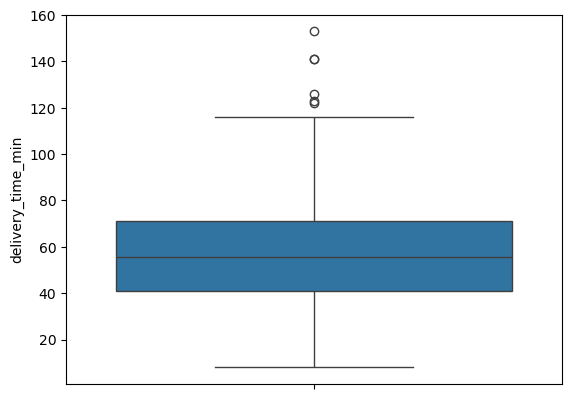

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(y = df_raw['delivery_time_min'])
plt.show()

#### Labelling string to numerical using LabelEncoder(as it gives 0,1,2,3...) as ml needs numerical data

In [20]:
print(df_raw['weather'].unique())

['Windy' 'Clear' 'Foggy' 'Rainy' 'Snowy' 'Unknown']


In [21]:
df = df_raw.copy()

In [22]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_columns = [
    'weather',
    'traffic_level',
    'time_of_day',
    'vehicle_type'
]

for col in categorical_columns:

    le = LabelEncoder()

    le.fit(df_raw[col].astype(str))

    df[col] = le.transform(df[col].astype(str))

    encoders[col] = le

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                1000 non-null   int64  
 1   distance_km             1000 non-null   float64
 2   weather                 1000 non-null   int64  
 3   traffic_level           1000 non-null   int64  
 4   time_of_day             1000 non-null   int64  
 5   vehicle_type            1000 non-null   int64  
 6   preparation_time_min    1000 non-null   int64  
 7   courier_experience_yrs  1000 non-null   float64
 8   delivery_time_min       1000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 70.4 KB


In [24]:
df_raw['weather'].unique()

array(['Windy', 'Clear', 'Foggy', 'Rainy', 'Snowy', 'Unknown'],
      dtype=object)

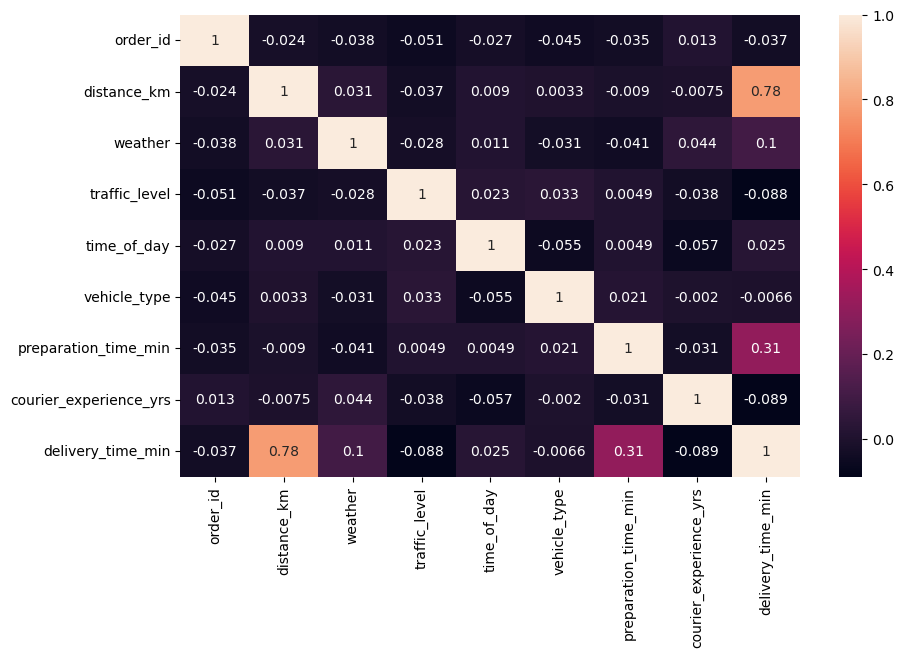

In [25]:
corr = df.corr()
plt.figure(figsize =(10,6))
sns.heatmap(corr,annot = True)
plt.show()

In [27]:
X = df.drop(['order_id','delivery_time_min'],axis=1)
y = df['delivery_time_min']

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

In [32]:
models = {
    "Linear Regression" :LinearRegression(),
    "Decision Tree" : DecisionTreeRegressor(random_state = 42),
    "Random Forest" : RandomForestRegressor(n_estimators = 100,random_state =42),
    "XG Boost" : XGBRegressor(random_state=42)
}

In [33]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
results=[]

In [34]:
for name,model in models.items():
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    rmse = mean_squared_error(y_test,pred) **0.5
    mae = mean_absolute_error(y_test,pred)
    r2 = r2_score(y_test,pred)

    results.append([
    name,
    rmse,
    mae,
    r2
    ])


In [35]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Rmse",
        "MAE",
        "R2 Score"
    ]
)
print(results_df)

               Model       Rmse        MAE  R2 Score
0  Linear Regression  10.522984   7.341058  0.752953
1      Decision Tree  15.302778  10.955000  0.477553
2      Random Forest  10.050365   7.034100  0.774646
3           XG Boost  10.509457   7.582079  0.753588


#### Here we can see that Random Forest is the best model here as it is giving the least mse,mae and high r2_score

### So now proceeding further with Random Forest


## Feature Importance Analysis

In [36]:
best_model = models["Random Forest"]

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending = False
)
print(importance_df)

                  Feature  Importance
0             distance_km    0.698834
5    preparation_time_min    0.155086
6  courier_experience_yrs    0.043937
2           traffic_level    0.031998
1                 weather    0.030289
3             time_of_day    0.025662
4            vehicle_type    0.014194


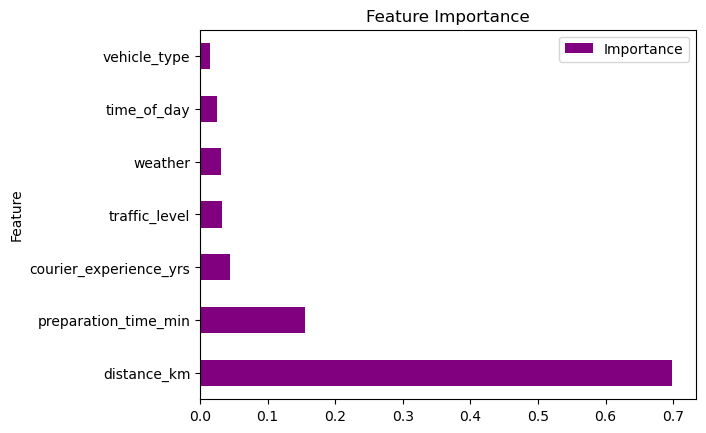

In [37]:
importance_df.plot(
    x= "Feature",
    y= "Importance",
    kind = "barh",
    color = "purple"
)

plt.title("Feature Importance")
plt.show()

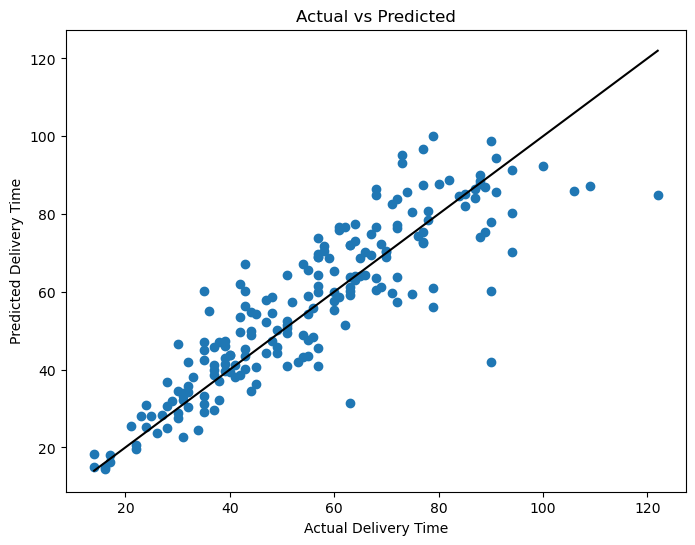

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,pred)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'k-'
)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted")
plt.show()

In [38]:
residuals = y_test - pred

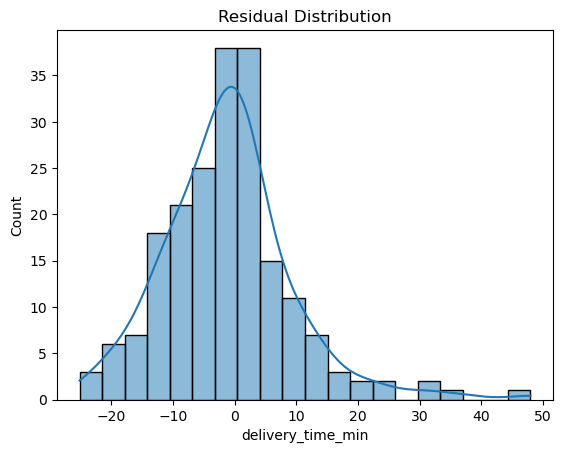

In [39]:
sns.histplot(residuals,kde =True)
plt.title("Residual Distribution")
plt.show()

### Hyperparameter Tuning

In [40]:
RandomForestRegressor(
    n_estimators = 300,
    max_depth =10,
    min_samples_split=5,
    random_state=42
)

RandomForestRegressor(max_depth=10, min_samples_split=5, n_estimators=300,
                      random_state=42)

In [41]:
from sklearn.model_selection import GridSearchCV

In [42]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth' : [5,10,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

In [43]:
rf = RandomForestRegressor(
    random_state=42
)

In [44]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

In [45]:
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=2)

In [46]:
print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [47]:
print(grid_search.best_score_)

0.7025769753910989


In [48]:
best_model = grid_search.best_estimator_


In [49]:
pred = best_model.predict(X_test)

In [50]:
print("R2",r2_score(y_test,pred))

R2 0.7853712317824


## this shows that tuning is not working so much here, so we can stick to the previous value of r2 i.e 0.77

In [51]:
import joblib

joblib.dump(best_model, 'delivery_model.pkl')

joblib.dump(encoders, 'encoders.pkl')

['encoders.pkl']

In [52]:
import joblib

joblib.dump(best_model, 'delivery_model.pkl')

['delivery_model.pkl']

In [53]:

import os

print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'Delivery project analysis  using SQL.sql', 'delivery_model.pkl', 'encoders.pkl', 'Food_Delivery_Times.csv', 'Untitled.ipynb']


In [54]:
import os

print(os.getcwd())

C:\Users\user\Food Delivery Time Prediction Project


In [55]:
import joblib

joblib.dump(
    best_model,
    r'C:\Users\user\Food Delivery Time Prediction Project\delivery_model.pkl'
)

joblib.dump(
    encoders,
    r'C:\Users\user\Food Delivery Time Prediction Project\encoders.pkl'
)

['C:\\Users\\user\\Food Delivery Time Prediction Project\\encoders.pkl']

In [57]:
print(encoders['weather'].classes_)

['Clear' 'Foggy' 'Rainy' 'Snowy' 'Unknown' 'Windy']
